# Netherlands Residential Building Archetypes for SESMG
### 3DBAG + BAG + TABULA + EP-Online — full reproducible pipeline

**Project:** FutureBEEing (FH Münster), Germany–Netherlands sustainable-neighbourhood tool.
**Goal:** turn 5.7 million Dutch residential buildings into a compact archetype table
(building type × construction period × morphology × roof orientation) carrying space-heat
demand, DHW, and PV roof area, for the sector-coupled energy model **SESMG**.
Reference method: Yang et al., *Applied Energy* 280 (2020) 115953 (Leiden).

This notebook is the whole pipeline, one step per section, each runnable on its own once
the section above it has run. It mirrors the NRW (North Rhine-Westphalia) workflow so the
two countries stay comparable.

---

### The one result to understand before reading the code

The heat-demand intensities in TABULA are a *theoretical* calculation. So is the
`Warmtebehoefte` field in the Dutch energy-label register (EP-Online, NTA 8800). Comparing
the two **cancels the prebound effect** — the well-documented gap between calculated and
measured consumption — and isolates the one free parameter, the refurbishment share `f`.

That comparison (Section 9) shows the pre-1975 Dutch stock sits at TABULA's *unrefurbished*
intensity: **`f = 0`, not the 0.77 a naive reading of national refurbishment rates suggests.**
The resulting national space-heat demand is **~106 TWh/yr (calculated)** against **~48 TWh/yr
(measured-equivalent)** — a factor of 2.2 that is the *prebound effect measured across 5.6
million buildings*, not a modelling error. Which of those two numbers SESMG should consume
(asset demand vs occupant demand) is a modelling decision, not a data one.

| Section | What it does |
|---|---|
| 1 | Configuration and paths |
| 2 | Load the 3DBAG residential buildings |
| 3 | Data quality — status, geometry flag, construction year, sentinels |
| 4 | Reference floor area from BAG gebruiksoppervlakte (pure `woonfunctie`) |
| 5 | Building-type classification + threshold sensitivity |
| 6 | TABULA periods, the sheet, and the join |
| 7 | Refurbishment state — the `f` parameter |
| 8 | DHW |
| 9 | **EP-Online validation: classification, area, and `f`** |
| 10 | Roof / PV attributes (orientation-split) |
| 11 | Clustering into archetypes |
| 12 | Pooling the long tail |
| 13 | Final validation summary and export |


## 1. Configuration

All tunable numbers live here. Paths are relative to `BASE_DIR`; put the three source
files and this notebook in the same folder, or edit `BASE_DIR`.

Two constants encode decisions that took the whole project to reach, so they are commented
in full: `F_REFURB = 0.0` (Section 9 proves it) and the classification thresholds
(validated at 98.2 % in Section 9).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("imports OK")

imports OK


In [4]:
BASE_DIR = r"C:\Users\zaito\futurebeeing"                 # <-- edit if the data lives elsewhere
DATA_DIR = os.path.join(BASE_DIR, "netherlands")        
FILE_BAG3D  = os.path.join(BASE_DIR, "bag3d_nl_woonpanden.geoparquet")
FILE_VBO    = os.path.join(BASE_DIR, "woon_vbo.gpkg")
FILE_TABULA = os.path.join(BASE_DIR, "netherlands_tabula.xlsx")
FILE_EPCSV  = os.path.join(BASE_DIR, "eponline", "v20260701_v4_csv.csv")  # optional, Section 9
OUT_DIR     = os.path.join(BASE_DIR, "nl_results")
os.makedirs(OUT_DIR, exist_ok=True)

# --- classification thresholds (own convention; the Leiden BAG type field is absent here) ---
# Validated against the EP-Online national register at 98.2% in Section 9.
PARTY_WALL_THR = 5.0     # m2   1 unit & <= 5  -> SFH (detached);  > 5 -> TH (attached)
AB_UNITS       = 13      # units  MFH = 2..12,  AB = >= 13   (threshold from Luis's thesis)
SIZE_CLASSES   = ["SFH", "TH", "MFH", "AB"]

# --- data-quality bounds (BAG sentinels & impossible values) ---
STATUS_DROP     = ("sloopvergunning", "buiten gebruik", "niet gerealiseerd", "bouw gestart")
YEAR_SENTINEL   = (1005,)          # BAG 'unknown bouwjaar'. 1450/1400/1350 are REAL years.
YEAR_MAX        = 2026
FOOTPRINT_BOUNDS = (10.0, 20000.0) # m2 per building
VBO_AREA_BOUNDS  = (10.0, 2000.0)  # m2 per verblijfsobject
REF_AREA_BOUNDS  = (10.0, 50000.0) # m2 per pand after summing

# --- refurbishment ---
PRE_REFURB_YEAR = 2000
F_REFURB = 0.0
# f is the fraction of the pre-2000 envelope refurbished to TABULA's "usual" package.
# EP-Online NTA 8800 (Section 9): periods 01-02 match TABULA heat_existing to 1.6% on
# ~880k labelled buildings, and the most-renovated segment (social housing) shows no
# refurbishment relative to TABULA's baseline. So f = 0. The Leiden component-rate mean
# of 0.7725 was an unfounded prior and is rejected.

# --- reference: national CALCULATED space-heat demand, TWh/yr ---
# NOT measured. EP-Online implies ~115 TWh. Measured-equivalent is ~48 TWh (a 2.2x
# prebound gap). Used only for a sanity band, never to fit f.
REF_TWH = (100.0, 120.0)

# --- clustering ---
K_MIN, K_MAX = 2, 10
SAMPLE_N     = 30_000       # k-selection sample; final fit uses ALL buildings
RANDOM_STATE = 42
MINIBATCH    = 5_000
MIN_CLUSTER_MEMBERS = 50
FLAT_OFFSET  = 100          # flat-roof cluster labels start at 100
NO_PV_LABEL  = -1
print("configuration loaded")

configuration loaded


## 2. Load the 3DBAG residential buildings

`bag3d_nl_woonpanden.geoparquet` was pre-processed from 3DBAG: residential panden only,
roof geometry summarised per building. It has **no native building-type field** and no
`gebruiksdoel`; `roof_type_osm` describes roof *shape*, not building form. That is why
classification (Section 5) is derived from morphology.

Geometry is not needed here, so we read attributes with `pandas`, which is ~4× faster than
`geopandas`. Note two dtype traps that break naive code: `quality_indicator` is **boolean**
(its `describe()` returns object and cannot be rounded), and several columns arrive
dictionary-encoded as **Categorical**.

In [5]:
NEEDED = ["building_id", "construction_year", "floor_count", "party_wall_area_m2",
          "flat_roof_area_m2", "pitched_roof_area_m2", "footprint_area_m2",
          "roof_type_osm", "quality_indicator", "status",
          "n_residential_units", "residential_area_m2", "avg_tilt_deg",
          "area_north_m2", "area_east_m2", "area_south_m2", "area_west_m2",
          "area_total_m2"]

bag = pd.read_parquet(FILE_BAG3D, columns=NEEDED)
print(f"buildings : {len(bag):,}")
print(f"dwellings : {bag['n_residential_units'].sum():,}")
print("\ndtypes (note: quality_indicator is bool, status is categorical):")
print(bag.dtypes.to_string())
bag.head(3)

buildings : 5,740,710
dwellings : 8,724,383

dtypes (note: quality_indicator is bool, status is categorical):
building_id              object
construction_year       float64
floor_count             float64
party_wall_area_m2      float64
flat_roof_area_m2       float64
pitched_roof_area_m2    float64
footprint_area_m2       float64
roof_type_osm            object
quality_indicator          bool
status                   object
n_residential_units       int64
residential_area_m2       int64
avg_tilt_deg            float64
area_north_m2           float64
area_east_m2            float64
area_south_m2           float64
area_west_m2            float64
area_total_m2           float64


,building_id,construction_year,floor_count,party_wall_area_m2,flat_roof_area_m2,pitched_roof_area_m2,footprint_area_m2,roof_type_osm,quality_indicator,status,n_residential_units,residential_area_m2,avg_tilt_deg,area_north_m2,area_east_m2,area_south_m2,area_west_m2,area_total_m2
0,0882100000000522,1925.0,2.0,0.0,47.560001,105.559998,112.879997,pitched,True,Pand in gebruik,1,210,1.75,0.00,17.21,0.00,0.0,17.21
1,0882100000000439,1925.0,2.0,0.0,0.000000,162.380005,125.559998,pitched,True,Pand in gebruik,1,220,26.87,29.68,21.28,0.00,0.0,50.96
2,0882100000000536,1925.0,2.0,0.0,31.040001,107.169998,119.730003,pitched,True,Pand in gebruik,1,195,23.42,65.44,35.39,27.18,0.0,128.01


## 3. Data quality

Four filters, each removing a specific BAG artefact. Nothing here is cosmetic — before
these ran, 13 buildings carrying the `999999` 'unknown-area' sentinel accounted for 1.63
TWh, and a single-dwelling 'house' with a 95,755 m² footprint sat in the SFH class.

- **`status`** — drop demolition-permit, out-of-use, not-realised, and construction-started
  panden. `Bouw gestart` has no occupants and its point cloud predates the roof.
  `Verbouwing pand` (renovation) and `niet ingemeten` (unsurveyed) are occupied and kept;
  the latter is flagged.
- **`quality_indicator`** — boolean; `False` marks a degraded LoD2.2 reconstruction. It does
  **not** affect heat demand (area comes from BAG, not geometry) but corrupts every
  roof/PV quantity. **Flag, never drop.**
- **`construction_year`** — `1005` is the sentinel for *unknown*. `1450/1400/1350/1250` are
  genuine medieval buildings; filtering below 1500 would delete ~1,800 real records.
- **footprint bounds** — remove impossible geometry.

In [6]:
b = bag.copy()
n0 = len(b)

# --- construction year ---
cy = b["construction_year"]
print(f"construction_year  NaN={cy.isna().sum():,}  "
      f"sentinel{YEAR_SENTINEL}={cy.isin(YEAR_SENTINEL).sum():,}  >{YEAR_MAX}={(cy>YEAR_MAX).sum():,}")
print("pre-1500 values (kept unless sentinel):")
print(cy[cy < 1500].value_counts().head(6).to_string())

# --- status & quality (dtype-safe printing) ---
print("\nstatus:\n" + b["status"].astype("object").value_counts().head(8).to_string())
print("\nquality_indicator (bool):\n" + b["quality_indicator"].astype("object").value_counts().to_string())

construction_year  NaN=0  sentinel(1005,)=86  >2026=0
pre-1500 values (kept unless sentinel):
construction_year
1450.0    1091
1400.0      96
1005.0      86
1350.0      44
1250.0      43
1475.0      27

status:
status
Pand in gebruik                     5703465
Verbouwing pand                       27492
Bouw gestart                           4684
Pand in gebruik (niet ingemeten)       3171
Sloopvergunning verleend               1791
Pand buiten gebruik                     107

quality_indicator (bool):
quality_indicator
True     5273723
False     466987


In [7]:
# apply the filters
st = b["status"].astype("object").astype("string")
drop_status = st.str.contains("|".join(STATUS_DROP), case=False, na=False)
print(f"dropping on status: {int(drop_status.sum()):,}")

fp_lo, fp_hi = FOOTPRINT_BOUNDS
print(f"footprint outside [{fp_lo:.0f},{fp_hi:.0f}] m2: "
      f"{int((~b['footprint_area_m2'].between(fp_lo,fp_hi)).sum()):,}  (max {b['footprint_area_m2'].max():,.0f})")

# derive the flags BEFORE filtering so indices stay aligned through reset_index
b["geom_quality_ok"]   = b["quality_indicator"].astype(bool)
b["status_unsurveyed"] = st.str.contains("niet ingemeten", na=False).values

b = b[~drop_status
      & b["footprint_area_m2"].between(fp_lo, fp_hi)
      & (b["n_residential_units"] > 0)
      & (b["area_total_m2"] > 0)
      & b["construction_year"].notna()
      & ~b["construction_year"].isin(YEAR_SENTINEL)
      & (b["construction_year"] <= YEAR_MAX)].copy().reset_index(drop=True)

print(f"\ndropped total : {n0-len(b):,} ({(n0-len(b))/n0:.4%})")
print(f"remaining     : {len(b):,}")
print(f"geom_quality_ok=False : {int((~b['geom_quality_ok']).sum()):,} "
      f"({(~b['geom_quality_ok']).mean():.1%}) - roof/PV unreliable, flagged not dropped")

dropping on status: 6,582
footprint outside [10,20000] m2: 2,423  (max 95,755)

dropped total : 9,302 (0.1620%)
remaining     : 5,731,408
geom_quality_ok=False : 465,517 (8.1%) - roof/PV unreliable, flagged not dropped


### 3.1 Roof-orientation invariant (a data fact, re-asserted)

The four cardinal areas sum to `area_total` **exactly**, which means flat roofs are binned
into compass directions by their face normals — a geometric artefact, not real orientation.
The consequence for PV (Section 10) is that flat area must be carried orientation-neutral
and never split by cardinal. We assert the invariant rather than trust it.

In [8]:
cardinals = ["area_north_m2","area_east_m2","area_south_m2","area_west_m2"]
ratio = b[cardinals].sum(axis=1) / b["area_total_m2"]
print("cardinal_sum / area_total:")
print(ratio.describe([.05,.5,.95]).round(6).to_string())
assert abs(ratio.mean() - 1) < 1e-3, "cardinal areas no longer sum to total"

flat_only = b[b["pitched_roof_area_m2"] == 0]
print(f"\nflat-only buildings: {len(flat_only):,}")
print(f"their avg_tilt_deg : mean {flat_only['avg_tilt_deg'].mean():.2f} deg (genuinely flat)")

cardinal_sum / area_total:
count    5.731408e+06
mean     1.000000e+00
std      6.100000e-05
min      9.979210e-01
5%       9.998730e-01
50%      1.000000e+00
95%      1.000126e+00
max      1.001258e+00

flat-only buildings: 476,375
their avg_tilt_deg : mean 0.60 deg (genuinely flat)


## 4. Reference floor area

TABULA's reference area `A_C,ref` is the **conditioned floor area on internal dimensions**
(TABULA CommonCalculationMethod, ch. 7). In the Dutch context that is
*gebruiksoppervlakte* under NEN 2580 — exactly what BAG stores as `oppervlakte` per
verblijfsobject (VBO).

Two subtleties decide the national total:

1. **Pure `woonfunctie` only.** A VBO tagged `winkelfunctie,woonfunctie` is one object whose
   `oppervlakte` covers the shop *and* the dwelling. Summing it into a residential heat
   demand is wrong. We sum only `gebruiksdoel == "woonfunctie"` exactly, and keep the mixed
   ones solely as a flag.
2. **Sentinels.** `oppervlakte == 999999` is BAG's 'unknown'. Bounded away.

The dwelling *count* still comes from all residential VBOs (that is the count, not the area).
Section 9 confirms this area against the register's `GebruiksoppervlakteThermischeZone` at
ratio 1.000.

In [9]:
import geopandas as gpd

# gebruiksdoel is a USE-FUNCTION field (woon / winkel / kantoor / industrie / zorg).
# It carries NO dwelling-form values, so it cannot classify SFH/TH/MFH/AB.
try:
    import pyogrio
    vbo = pyogrio.read_dataframe(FILE_VBO, layer="verblijfsobject",
                                 columns=["pand_identificatie","gebruiksdoel","oppervlakte"],
                                 read_geometry=False)
except Exception as e:
    print("pyogrio unavailable, using geopandas:", type(e).__name__)
    vbo = gpd.read_file(FILE_VBO, layer="verblijfsobject", ignore_geometry=True)
print(f"VBO rows: {len(vbo):,}")

# (1) sentinels
lo, hi = VBO_AREA_BOUNDS
print(f"oppervlakte >= 999999 (sentinel): {int(vbo['oppervlakte'].ge(999999).sum()):,}")
vbo = vbo[vbo["oppervlakte"].between(lo, hi)]

gd = vbo["gebruiksdoel"].astype("object").astype("string")
any_woon  = gd.str.contains("woon", case=False, na=False)   # residential FILTER + count
pure_woon = gd.eq("woonfunctie")                            # reference AREA
print(f"residential VBOs: {int(any_woon.sum()):,}  pure woonfunctie: {int(pure_woon.sum()):,} "
      f"({pure_woon.sum()/max(any_woon.sum(),1):.1%})")

VBO rows: 8,645,373
oppervlakte >= 999999 (sentinel): 195
residential VBOs: 8,640,535  pure woonfunctie: 8,465,869 (98.0%)


In [10]:
# (2) reference area = pure woonfunctie only; dwelling count = all residential
go = (vbo[pure_woon].groupby("pand_identificatie")
        .agg(ref_area_m2=("oppervlakte","sum"), vbo_units_pure=("oppervlakte","size")).reset_index())
allres = (vbo[any_woon].groupby("pand_identificatie")
            .agg(vbo_units=("oppervlakte","size")).reset_index())
mixed  = (vbo[any_woon & ~pure_woon].groupby("pand_identificatie").size()
            .rename("n_mixed_use_vbo").reset_index())
go = (allres.merge(go, on="pand_identificatie", how="left")
            .merge(mixed, on="pand_identificatie", how="left"))
go["n_mixed_use_vbo"] = go["n_mixed_use_vbo"].fillna(0).astype(int)

# (3) bound the summed area
lo, hi = REF_AREA_BOUNDS
go.loc[go["ref_area_m2"].notna() & ~go["ref_area_m2"].between(lo,hi), "ref_area_m2"] = np.nan
print(f"panden with a residential VBO : {len(go):,}")
print(f"of which NO pure-woonfunctie  : {int(go['ref_area_m2'].isna().sum()):,}")

panden with a residential VBO : 5,735,013
of which NO pure-woonfunctie  : 110,950


In [11]:
# join onto the buildings; DROP panden that have only mixed VBOs (farmhouse-as-industry etc.)
df = b.merge(go, left_on="building_id", right_on="pand_identificatie", how="left")

r = (df["residential_area_m2"] / df["ref_area_m2"])
m = df["ref_area_m2"].notna() & (df["residential_area_m2"] > 0)
print("residential_area_m2 / pure-woonfunctie GO:  median "
      f"{r[m].median():.3f}  p05 {r[m].quantile(.05):.3f}  p95 {r[m].quantile(.95):.3f}")

miss = df["ref_area_m2"].isna()
print(f"\npanden with no pure-woonfunctie VBO: {int(miss.sum()):,} ({miss.mean():.2%})")
print(f"  their mixed-use rate: {(df.loc[miss,'n_mixed_use_vbo']>0).mean():.1%}  -> dropping")
df = df[~miss].copy()
df["has_mixed_use"] = df["n_mixed_use_vbo"].fillna(0).gt(0)

tot_go, tot_dwl = df["ref_area_m2"].sum()/1e6, df["n_residential_units"].sum()
print(f"\nnational residential GO : {tot_go:,.0f} Mm2")
print(f"dwellings               : {tot_dwl:,}")
print(f"GO per dwelling         : {tot_go*1e6/tot_dwl:.1f} m2   (CBS ~120)")
print(f"buildings remaining     : {len(df):,}")

residential_area_m2 / pure-woonfunctie GO:  median 1.000  p05 1.000  p95 1.000

panden with no pure-woonfunctie VBO: 114,754 (2.00%)
  their mixed-use rate: 97.7%  -> dropping

national residential GO : 983 Mm2
dwellings               : 8,510,012
GO per dwelling         : 115.5 m2   (CBS ~120)
buildings remaining     : 5,616,654


## 5. Building-type classification

The Leiden model reads building type from a BAG field this dataset lacks, so the rules
below are a morphological convention:

```
SFH = 1 unit & party_wall <= 5 m2      (detached)
TH  = 1 unit & party_wall >  5 m2      (attached; semi-detached folded into TH)
MFH = 2..12 units
AB  = >= 13 units
```

Both thresholds were chosen by hand, so both are swept. **Section 9 scores this rule at
98.2 % against the national register** — the sweep here only shows it is *insensitive*
(all shares move < 1 pp across a 3× threshold range), which is a separate reassurance.

Building-level and dwelling-level shares differ enormously (one apartment block is one
building and 40 dwellings); state which you mean whenever comparing to CBS.

In [12]:
def classify(frame, pw=PARTY_WALL_THR, ab=AB_UNITS):
    u, p = frame["n_residential_units"], frame["party_wall_area_m2"]
    return pd.Series(np.select(
        [(u==1)&(p<=pw), (u==1)&(p>pw), (u>1)&(u<ab), (u>=ab)],
        ["SFH","TH","MFH","AB"], default="UNKNOWN"), index=frame.index)

df["building_type"] = classify(df)
assert (df["building_type"] != "UNKNOWN").all()

bld = df["building_type"].value_counts()
dwl = df.groupby("building_type")["n_residential_units"].sum()
print(pd.DataFrame({"buildings":bld, "buildings_%":(bld/bld.sum()*100).round(1),
                    "dwellings":dwl, "dwellings_%":(dwl/dwl.sum()*100).round(1)}
                   ).loc[SIZE_CLASSES].to_string())

               buildings  buildings_%  dwellings  dwellings_%
building_type                                                
SFH               974554         17.4     974554         11.5
TH               4257386         75.8    4257386         50.0
MFH               335338          6.0    1332435         15.7
AB                 49376          0.9    1945637         22.9


In [13]:
# threshold sensitivity — both thresholds are own conventions
rows=[]
for pw in (3.0,5.0,10.0):
    for ab in (10,13,20):
        s = classify(df, pw, ab).value_counts(normalize=True)*100
        rows.append({"party_wall_thr":pw,"ab_units":ab,
                     **{k:round(s.get(k,0),1) for k in SIZE_CLASSES}})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
spread = {k: round(sens[k].max()-sens[k].min(),1) for k in SIZE_CLASSES}
print("\nspread across the whole grid (pp):", spread)
print("< 1 pp everywhere -> classification is insensitive to the thresholds")

 party_wall_thr  ab_units  SFH   TH  MFH  AB
            3.0        10 17.3 75.9  5.7 1.1
            3.0        13 17.3 75.9  6.0 0.9
            3.0        20 17.3 75.9  6.2 0.6
            5.0        10 17.4 75.8  5.7 1.1
            5.0        13 17.4 75.8  6.0 0.9
            5.0        20 17.4 75.8  6.2 0.6
           10.0        10 17.8 75.4  5.7 1.1
           10.0        13 17.8 75.4  6.0 0.9
           10.0        20 17.8 75.4  6.2 0.6

spread across the whole grid (pp): {'SFH': np.float64(0.5), 'TH': np.float64(0.5), 'MFH': np.float64(0.5), 'AB': np.float64(0.5)}
< 1 pp everywhere -> classification is insensitive to the thresholds


## 6. TABULA periods, sheet, and join

Period boundaries confirmed from the live WebTool (`webtool.building-typology.eu`):

```
01 = ...1964   02 = 1965-1974   03 = 1975-1991
04 = 1992-2005 05 = 2006-2014   06 = 2015...
```

Heat demand is read from **Chart 1: "(Net/Gross) Energy Need for Heating"** — not Chart 2
(delivered energy, contaminated by boiler efficiency), not the system-dependent right-panel
values. The sheet's third column is **DHW**, not a heating state; the three heating states
are columns 2, 4, 5.

We also assert the sheet's internal consistency. It fails in 12 places: newer periods
"needing" more heat. Period `06` postdates the NL-TABULA dataset and was hand-filled; it is
the main offender and Section 9 shows it overstates demand by 13 %.

In [14]:
tab = pd.read_excel(FILE_TABULA, sheet_name="Netherlands")
tab.columns = ["tabula_key","heat_existing","dhw","heat_usual_refurb","heat_advanced_refurb"]
tab["type"]   = tab["tabula_key"].str.split(".").str[2]
tab["period"] = tab["tabula_key"].str.split(".").str[3]
print(f"TABULA rows: {len(tab)} (4 types x 6 periods)")
print("\nheat_existing kWh/(m2 a):")
print(tab.pivot(index="period", columns="type", values="heat_existing")[SIZE_CLASSES].to_string())
print("\ndhw (constant per type, NOT per period):")
print(tab.groupby("type")["dhw"].unique().to_string())

TABULA rows: 24 (4 types x 6 periods)

heat_existing kWh/(m2 a):
type      SFH     TH    MFH     AB
period                            
01      166.1  156.7  127.8  128.3
02      141.1  122.5  104.2  103.7
03      103.8   95.6   91.7   90.8
04       83.2   69.4   67.0   65.3
05       68.5   59.4   56.5   57.8
06       68.8   60.3   58.2   59.1

dhw (constant per type, NOT per period):
type
AB     [15]
MFH    [15]
SFH    [10]
TH     [10]


In [15]:
# consistency check
bad=[]
for typ,g in tab.sort_values("period").groupby("type"):
    for col in ("heat_existing","heat_usual_refurb","heat_advanced_refurb"):
        v=g[col].values
        for i in range(len(v)-1):
            if v[i+1]>v[i]: bad.append((typ,col,g["period"].values[i],g["period"].values[i+1]))
print(f"monotonicity inversions (newer needs MORE heat): {len(bad)}")
for x in bad: print("  ", x)
print("\nperiod 06 was hand-filled; Section 9 shows it overstates demand ~13%")
assert (tab["heat_usual_refurb"]    <= tab["heat_existing"]).all()
assert (tab["heat_advanced_refurb"] <= tab["heat_usual_refurb"]).all()

monotonicity inversions (newer needs MORE heat): 12
   ('AB', 'heat_existing', '05', '06')
   ('AB', 'heat_usual_refurb', '04', '05')
   ('AB', 'heat_advanced_refurb', '02', '03')
   ('MFH', 'heat_existing', '05', '06')
   ('MFH', 'heat_usual_refurb', '02', '03')
   ('MFH', 'heat_usual_refurb', '04', '05')
   ('MFH', 'heat_advanced_refurb', '02', '03')
   ('SFH', 'heat_existing', '05', '06')
   ('SFH', 'heat_usual_refurb', '04', '05')
   ('SFH', 'heat_advanced_refurb', '05', '06')
   ('TH', 'heat_existing', '05', '06')
   ('TH', 'heat_usual_refurb', '04', '05')

period 06 was hand-filled; Section 9 shows it overstates demand ~13%


In [16]:
# period bins + join
df["period"] = pd.cut(df["construction_year"],
                      [-np.inf,1964,1974,1991,2005,2014,np.inf],
                      labels=["01","02","03","04","05","06"]).astype(str)
assert not (df["period"]=="nan").any()
df["tabula_key"] = "NL.N." + df["building_type"] + "." + df["period"]
m = df.merge(tab.drop(columns=["type","period"]), on="tabula_key", how="left")
assert m["heat_existing"].isna().sum() == 0, "unmatched TABULA keys"
print("buildings with no TABULA match:", int(m["heat_existing"].isna().sum()))
print("\ntype x period (buildings):")
print(pd.crosstab(m["building_type"], m["period"]).loc[SIZE_CLASSES].to_string())

buildings with no TABULA match: 0

type x period (buildings):
period              01      02       03      04      05      06
building_type                                                  
SFH             378902  114442   170828  174968   60726   74688
TH             1260752  758383  1153694  591396  230827  262334
MFH             228021   16670    52543   21670    9545    6889
AB                6078    7145    11587   11032    7590    5944


## 7. Refurbishment state

Every building carries three TABULA states — `existing`, `usual refurbishment`,
`advanced` — but nothing yet says which applies. The parameter is `f`, the fraction of the
pre-2000 envelope refurbished, applied as a deterministic interpolation:

$$q = q_\text{existing} - f\,(q_\text{existing} - q_\text{usual}),\quad\text{pre-2000 only}$$

Deterministic (not random Bernoulli sampling) keeps the pipeline reproducible; since SESMG
consumes archetype means, the two converge anyway.

**`F_REFURB = 0.0`, and Section 9 is where that number comes from.** The sweep below shows
how sensitive the national total is to `f` — from 106 TWh at `f=0` to 61 TWh at `f=1` — which
is exactly why the value cannot be guessed and had to be measured against the register.

> The reference band here is **calculated** demand (~100-120 TWh). It is a sanity check,
> never a target to fit `f` to. Fitting `f` to *measured* consumption would make it absorb
> the prebound effect — see Section 9.

In [17]:
def apply_refurb(frame, f, pre_year=PRE_REFURB_YEAR):
    pre = (frame["construction_year"] < pre_year).astype(float)
    return frame["heat_existing"] - f*pre*(frame["heat_existing"] - frame["heat_usual_refurb"])

A = m["ref_area_m2"].to_numpy()
print("national space-heat demand vs f  (CALCULATED, not measured):")
sweep=[]
for f in (0.0,0.2,0.4,0.6,0.7725,0.8,1.0):
    twh = float((apply_refurb(m,f).to_numpy()*A).sum())/1e9
    sweep.append((f,twh))
    tag = "   <- Leiden prior, REJECTED (Section 9)" if abs(f-0.7725)<1e-6 else ("  <- USED" if f==0.0 else "")
    print(f"  f={f:<6} -> {twh:6.1f} TWh{tag}")

national space-heat demand vs f  (CALCULATED, not measured):
  f=0.0    ->  106.2 TWh  <- USED
  f=0.2    ->   97.1 TWh
  f=0.4    ->   88.0 TWh
  f=0.6    ->   79.0 TWh
  f=0.7725 ->   71.1 TWh   <- Leiden prior, REJECTED (Section 9)
  f=0.8    ->   69.9 TWh
  f=1.0    ->   60.8 TWh


In [18]:
# apply f = 0 and materialise per-building demand
m["heat_kwh_m2a"] = apply_refurb(m, F_REFURB)
m["heat_kwh_yr"]  = m["heat_kwh_m2a"] * m["ref_area_m2"]
print(f"f used          : {F_REFURB}")
print(f"mean intensity  : {m['heat_kwh_yr'].sum()/m['ref_area_m2'].sum():.1f} kWh/m2a")
print(f"national total  : {m['heat_kwh_yr'].sum()/1e9:.1f} TWh/yr (calculated)")
print("\nby type:")
print(m.groupby("building_type").agg(
    buildings=("building_id","size"), dwellings=("n_residential_units","sum"),
    TWh=("heat_kwh_yr", lambda s: round(s.sum()/1e9,1)),
    kWh_m2a=("heat_kwh_m2a","mean")).loc[SIZE_CLASSES].round(1).to_string())

f used          : 0.0
mean intensity  : 108.0 kWh/m2a
national total  : 106.2 TWh/yr (calculated)

by type:
               buildings  dwellings   TWh  kWh_m2a
building_type                                     
SFH               974554     974554  24.1    123.8
TH               4257386    4257386  58.6    110.7
MFH               335338    1332435  11.7    113.6
AB                 49376    1945637  11.8     82.7


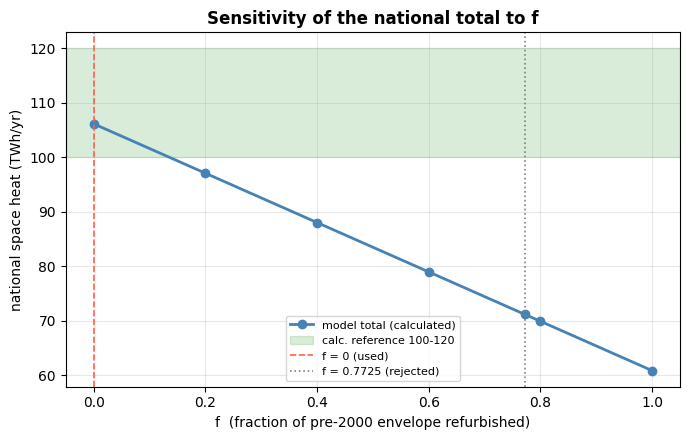

In [19]:
# visualise the f-sweep against the calculated reference band
fig, ax = plt.subplots(figsize=(7,4.5))
fs,tw = zip(*sweep)
ax.plot(fs, tw, marker="o", color="steelblue", lw=2, label="model total (calculated)")
ax.axhspan(REF_TWH[0], REF_TWH[1], color="green", alpha=.15, label=f"calc. reference {REF_TWH[0]:.0f}-{REF_TWH[1]:.0f}")
ax.axvline(0.0,    color="tomato", ls="--", lw=1.2, label="f = 0 (used)")
ax.axvline(0.7725, color="grey",   ls=":",  lw=1.2, label="f = 0.7725 (rejected)")
ax.set_xlabel("f  (fraction of pre-2000 envelope refurbished)")
ax.set_ylabel("national space heat (TWh/yr)")
ax.set_title("Sensitivity of the national total to f", fontweight="bold")
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"f_sweep.pdf"), bbox_inches="tight"); plt.show()

## 8. Domestic hot water

`dhw` is 10 kWh/(m²·a) for SFH/TH and 15 for MFH/AB — constant per *type*, not per period.
It is a **TABULA cross-country standard constant**, not a Dutch-specific value.

Kept as a **separate** demand series, for two reasons: SESMG optimises DHW separately (it
sits at a different temperature level, ~60 °C vs 35-55 °C, and collapsing the two destroys
the heat-pump COP the model exists to compute); and DHW scales with *occupants*, not floor
area, so it is normalised per dwelling. (National DHW is ~4 % high because BAG counts ~4 %
more `woonfunctie` objects than CBS counts dwellings — see Section 13.)

In [20]:
REF_DWELLING_M2 = 100.0
m["dhw_kwh_yr"] = m["dhw"] * REF_DWELLING_M2 * m["n_residential_units"]
print(f"DHW national (per-dwelling normalised) : {m['dhw_kwh_yr'].sum()/1e9:.1f} TWh/yr")
print(f"per dwelling                           : {m['dhw_kwh_yr'].sum()/m['n_residential_units'].sum():,.0f} kWh/yr")
print("kept SEPARATE from space heat for SESMG (different temperature level)")

DHW national (per-dwelling normalised) : 10.1 TWh/yr
per dwelling                           : 1,193 kWh/yr
kept SEPARATE from space heat for SESMG (different temperature level)


## 9. EP-Online validation — the analytical core

This section is why the numbers above are trustworthy. **EP-Online** (RVO) publishes every
registered Dutch energy label. Under NTA 8800 each carries `Warmtebehoefte`: a **calculated**
net space-heat need in kWh/(m²·a), per address, keyed on `BAGPandIDs`. It validates three
things independently, each on hundreds of thousands of buildings:

1. **Classification** (`Gebouwtype` is the dwelling-form ground truth) — scores the
   `party_wall > 5` rule.
2. **Reference area** (`GebruiksoppervlakteThermischeZone` is the thermal-zone GO) — checks
   our `ref_area_m2`.
3. **Refurbishment `f`** — because both TABULA and NTA 8800 are *calculated*, comparing them
   cancels the prebound effect and isolates `f`.

> **This section is optional.** If you don't have the EP-Online file, skip to Section 10;
> the pipeline runs without it. To get it: request a key at `apikey.ep-online.nl`, then
> download the monthly `v*_v4_csv.zip` totaalbestand from `ep-online.nl/PublicData`, and
> unzip it into `BASE_DIR/eponline/`.

**File format traps:** two preamble lines (`skiprows=2`), `sep=";"`, **decimal comma**
(`decimal=","`). Use `Warmtebehoefte`, not `Energiebehoefte` (the latter is BENG-1 and
includes cooling). Only ~56 % of woningbouw rows are NTA 8800; only ~49 % carry
`BAGPandIDs`. Raw maxima are absurd (10.8M kWh/m²·a) so bound the columns.

In [21]:
EP_AVAILABLE = os.path.exists(FILE_EPCSV)
print("EP-Online file present:", EP_AVAILABLE, "\n", FILE_EPCSV)

TYPE_MAP = {   # NTA 8800 Gebouwtype vocabulary only
    "Vrijstaande woning":"SFH", "Twee-onder-één-kap":"TH",
    "Rijwoning hoek":"TH", "Rijwoning tussen":"TH",
    "Appartement":"APT", "Maisonnette":"APT", "Galerijwoning":"APT", "Portiekwoning":"APT",
}   # NB: 'Appartement' does NOT separate MFH from AB
WB_BOUNDS, GO_BOUNDS = (0.0, 500.0), (10.0, 2000.0)

EP-Online file present: True 
 C:\Users\zaito\futurebeeing\eponline\v20260701_v4_csv.csv


In [22]:
if EP_AVAILABLE:
    USE = ["Berekeningstype","Gebouwklasse","Gebouwtype","BAGPandIDs","Bouwjaar",
           "GebruiksoppervlakteThermischeZone","Energieklasse","Energiebehoefte","Warmtebehoefte"]
    STR = ["BAGPandIDs","Gebouwklasse","Gebouwtype","Berekeningstype","Energieklasse"]
    parts, n_in = [], 0
    for ch in pd.read_csv(FILE_EPCSV, sep=";", skiprows=2, usecols=USE, decimal=",",
                          dtype={c:"string" for c in STR}, encoding="utf-8",
                          encoding_errors="replace", low_memory=False, chunksize=500_000):
        n_in += len(ch)
        ch = ch[ch.Gebouwklasse.eq("W")
                & ch.Berekeningstype.str.contains("NTA 8800", na=False)
                & ch.BAGPandIDs.notna()
                & ch.Warmtebehoefte.between(*WB_BOUNDS, inclusive="right")
                & ch.GebruiksoppervlakteThermischeZone.between(*GO_BOUNDS)
                & (ch.Energiebehoefte >= ch.Warmtebehoefte)]
        parts.append(ch)
    ep = pd.concat(parts, ignore_index=True)
    print(f"{n_in:,} rows -> {len(ep):,} usable NTA 8800 with BAGPandIDs ({len(ep)/n_in:.1%})")
else:
    print("skipping Section 9 (no EP-Online file)")

6,185,693 rows -> 1,774,843 usable NTA 8800 with BAGPandIDs (28.7%)


In [23]:
if EP_AVAILABLE:
    # one row per pand; Warmtebehoefte is per-m2 so aggregate area-weighted
    ep = ep.assign(BAGPandIDs=ep.BAGPandIDs.str.split(",")).explode("BAGPandIDs")
    ep["BAGPandIDs"] = ep.BAGPandIDs.str.strip()
    ep["wxg"] = ep.Warmtebehoefte * ep.GebruiksoppervlakteThermischeZone
    g = ep.groupby("BAGPandIDs")
    pand = pd.DataFrame({
        "ep_labels": g.size(),
        "ep_go_m2":  g.GebruiksoppervlakteThermischeZone.sum(),
        "ep_wb_kwh_m2a": g.wxg.sum()/g.GebruiksoppervlakteThermischeZone.sum(),
        "ep_gebouwtype": g.Gebouwtype.agg(lambda s: s.mode().iat[0] if len(s.mode()) else pd.NA),
    }).reset_index().rename(columns={"BAGPandIDs":"building_id"})
    j = m.assign(building_id=m.building_id.astype(str)).merge(pand, on="building_id", how="inner")
    print(f"matched buildings: {len(j):,} ({len(j)/len(m):.1%} of stock, "
          f"{j.n_residential_units.sum()/m.n_residential_units.sum():.1%} of dwellings)")
    print("\ncoverage by type x period (%), highest for social housing AB/MFH:")
    cov = (j.groupby(['building_type','period']).size()/m.groupby(['building_type','period']).size()*100)
    print(cov.unstack().round(1).to_string())

matched buildings: 945,501 (16.8% of stock, 32.5% of dwellings)

coverage by type x period (%), highest for social housing AB/MFH:
period           01    02    03    04    05    06
building_type                                    
AB             65.8  70.7  63.3  78.1  77.9  61.6
MFH            35.7  35.6  35.5  45.0  45.6  45.5
SFH             5.8   6.0   5.2   9.4  13.2  21.1
TH             15.6  16.5  13.8  15.5  21.9  32.9


### 9.1 Classification vs the national register

`Gebouwtype` is what the label surveyor recorded. Comparing it to our morphology rule scores
the invented `party_wall > 5` threshold directly. (`Appartement` cannot separate MFH from
AB, so only SFH/TH are testable here.)

In [24]:
if EP_AVAILABLE:
    j["ep_class"] = j.ep_gebouwtype.map(TYPE_MAP)
    sub = j[j.ep_class.notna() & j.ep_class.ne("APT") & j.building_type.isin(["SFH","TH"])]
    ct = pd.crosstab(sub.building_type, sub.ep_class, normalize="index")*100
    print("row = our morphology rule, column = register Gebouwtype (%):")
    print(ct.round(1).to_string())
    print(f"\nAGREEMENT: {(sub.building_type==sub.ep_class).mean():.1%} on {len(sub):,} buildings")
    print("the invented party_wall > 5 threshold, scored against ground truth")

row = our morphology rule, column = register Gebouwtype (%):
ep_class        SFH    TH
building_type            
SFH            96.8   3.2
TH              1.7  98.3

AGREEMENT: 98.2% on 779,329 buildings
the invented party_wall > 5 threshold, scored against ground truth


### 9.2 Reference area vs the thermal-zone GO

On panden where *every* dwelling is labelled, `ref_area_m2` (summed dwelling GO) should equal
`GebruiksoppervlakteThermischeZone`. If MFH/AB came back below 1.0 it would mean the thermal
zone includes conditioned common circulation our area omits. It does not — both conventions
exclude it. (Partial-coverage panden give ratios of 2-4, which measure *label coverage*, not
area; hence the full-coverage filter.)

In [25]:
if EP_AVAILABLE:
    full = j[(j.n_residential_units>1) & (j.ep_labels==j.n_residential_units)].copy()
    full["r"] = full.ref_area_m2 / full.ep_go_m2
    print(f"fully-labelled multi-dwelling panden: {len(full):,}")
    print(full.groupby("building_type").r.describe([.05,.5,.95]).round(3).to_string())
    print("\nratio ~1.0 for MFH and AB -> no common-circulation understatement")

fully-labelled multi-dwelling panden: 29,263
                 count   mean    std    min     5%    50%    95%    max
building_type                                                          
AB              5213.0  0.999  0.096  0.033  0.928  1.000  1.086  4.110
MFH            24050.0  0.995  0.139  0.033  0.832  0.996  1.154  5.052

ratio ~1.0 for MFH and AB -> no common-circulation understatement


### 9.3 The refurbishment parameter `f`

Both quantities are calculated, so the prebound effect cancels. We compare NTA 8800
`Warmtebehoefte` to TABULA `heat_existing` per type × period. Use the **ratio**, not an
"implied f": the denominator `(existing - usual)` collapses toward zero for post-2000
periods and produces meaningless blow-ups.

In [26]:
if EP_AVAILABLE:
    TAB_EX = {t:[tab[(tab.type==t)&(tab.period==p)].heat_existing.iat[0] for p in
                 ["01","02","03","04","05","06"]] for t in SIZE_CLASSES}
    rows=[]
    for bt in SIZE_CLASSES:
        for i,per in enumerate(["01","02","03","04","05","06"]):
            gg = j[(j.building_type==bt)&(j.period==per)]
            if len(gg) < 100: continue
            obs = float(np.average(gg.ep_wb_kwh_m2a, weights=gg.ref_area_m2))
            rows.append((bt,per,len(gg),obs,TAB_EX[bt][i], obs/TAB_EX[bt][i]))
    r = pd.DataFrame(rows, columns=["type","period","n","NTA8800","TABULA_existing","ratio"])
    print("NTA8800 / TABULA_existing, per type x period:")
    print(r.to_string(index=False))
    print("\nn-weighted ratio by period:")
    for per,gp in r.groupby("period"):
        print(f"  {per}  {np.average(gp.ratio, weights=gp.n):.3f}")
    pre = r[r.period.isin(["01","02"])]
    print(f"\npre-1975 (periods 01-02) ratio: {np.average(pre.ratio, weights=pre.n):.3f}")
    print("~1.0 -> pre-1975 stock is at TABULA's UNREFURBISHED intensity -> f = 0")
    print("period 06 ratio ~0.87 -> TABULA's hand-filled rows overstate demand ~13%")

NTA8800 / TABULA_existing, per type x period:
type period      n    NTA8800  TABULA_existing    ratio
 SFH     01  21890 177.714661            166.1 1.069926
 SFH     02   6903 164.487337            141.1 1.165750
 SFH     03   8930 139.633937            103.8 1.345221
 SFH     04  16427 106.771962             83.2 1.283317
 SFH     05   8033  91.082232             68.5 1.329668
 SFH     06  15787  70.358291             68.8 1.022650
  TH     01 196637 147.073168            156.7 0.938565
  TH     02 125342 119.110116            122.5 0.972327
  TH     03 159564 110.348698             95.6 1.154275
  TH     04  91501  91.209229             69.4 1.314254
  TH     05  50444  75.671398             59.4 1.273929
  TH     06  86361  50.904259             60.3 0.844183
 MFH     01  81291 137.199367            127.8 1.073547
 MFH     02   5934 120.695457            104.2 1.158306
 MFH     03  18648 102.301361             91.7 1.115609
 MFH     04   9748  83.317402             67.0 1.243543
 M

**Conclusion of Section 9.** Periods 01-02 agree to within ~1.6 % across ~880 k buildings;
the most-renovated segment (social housing, AB/MFH, 62-78 % coverage) shows no refurbishment
relative to TABULA's baseline. Therefore **`f = 0`**, and Section 7's `F_REFURB = 0.0` is
correct. The calculated national total (~106 TWh) sits ~2.2× above the measured-equivalent
(~48 TWh) — the **prebound effect**, per *Majcen, Itard & Visscher (2013), Energy Policy 54*,
a study of ~200,000 Dutch dwellings under this same labelling scheme. Which figure SESMG
consumes (asset vs occupant demand) is a modelling decision.

## 10. Roof and PV attributes

Every building gets three PV variables, following the NRW convention so the two countries
stay comparable:

- **south** and **east-west** roof area (gabled roofs), clustered as two independent
  variables — a symmetric saddle roof has near-equal east and west faces, so combining them
  loses nothing;
- **flat** roof area, carried orientation-neutral;
- **north is excluded** entirely (poor yield at Dutch latitudes).

Two NL-specific corrections to the NRW recipe:

1. **Orientation comes only from *pitched* area.** Because the cardinals sum to `area_total`
   (Section 3.1), a flat roof would otherwise be split across compass directions. We scale
   the cardinal areas by the pitched share.
2. **Flat is detected by `pitched_roof_area_m2 == 0`, not by `avg_tilt < 10°`.** `avg_tilt_deg`
   is a building-level average, so a pitched roof with a flat extension would be
   misclassified by a tilt threshold. The area test is exact.

In [27]:
def roof_pv_attributes(frame):
    f = frame.copy()
    pit, flat = f["pitched_roof_area_m2"], f["flat_roof_area_m2"]
    share = (pit / (pit+flat).replace(0, np.nan)).fillna(0.0)   # pitched fraction of roof
    for d in ("north","east","south","west"):
        f[f"pv_pitched_{d}_m2"] = f[f"area_{d}_m2"] * share
    f["pv_south_m2"]    = f["pv_pitched_south_m2"]
    f["pv_eastwest_m2"] = f["pv_pitched_east_m2"] + f["pv_pitched_west_m2"]
    f["pv_flat_m2"]     = flat
    f["roof_category"]  = np.where(pit.eq(0), "flat", "gabled")
    f["has_pv_area"]    = np.where(f.roof_category.eq("flat"),
                                   f.pv_flat_m2.gt(0),
                                   (f.pv_south_m2>0) | (f.pv_eastwest_m2>0))
    return f

m = roof_pv_attributes(m)
print("roof_category:\n" + m.roof_category.value_counts().to_string())
print(f"\nno usable PV area (north-only or zero roof): {int((~m.has_pv_area).sum()):,} "
      f"({(~m.has_pv_area).mean():.1%})")
print("\nnational usable PV area (GROSS tilted surface, m2):")
for c in ["pv_south_m2","pv_eastwest_m2","pv_flat_m2"]:
    print(f"  {c:<16} {m[c].sum()/1e6:6.0f} Mm2")
print(f"  {'pv_north (EXCLUDED)':<16} {m['pv_pitched_north_m2'].sum()/1e6:6.0f} Mm2")
print("\nall four cardinals ~equal -> Dutch roof orientation is uniform;")
print("the north-exclusion convention discards ~25% of pitched area.")

roof_category:
roof_category
gabled    5146417
flat       470237

no usable PV area (north-only or zero roof): 37,590 (0.7%)

national usable PV area (GROSS tilted surface, m2):
  pv_south_m2         117 Mm2
  pv_eastwest_m2      238 Mm2
  pv_flat_m2          203 Mm2
  pv_north (EXCLUDED)    118 Mm2

all four cardinals ~equal -> Dutch roof orientation is uniform;
the north-exclusion convention discards ~25% of pitched area.


## 11. Clustering into archetypes

Within each `type × period` cell, buildings are clustered on two axes:

- a **morphology** cluster on size (`ref_area_m2`, footprint, floors, party-wall, units);
- **roof** clusters on the PV variables from Section 10 (south × east-west for gabled,
  flat separately, `+100` label offset so a flat cluster is never confused with a gabled one).

`k` per variable is chosen by the elbow of within-cluster inertia, evaluated on a sample for
speed, then the final fit uses all buildings via `MiniBatchKMeans`. Morphology and roof carry
*independent* information — a four-storey block and a bungalow with the same footprint share a
roof but differ four-fold in floor area — so both axes earn their place.

In [28]:
def elbow_k(values, kmax=6):
    n = len(values)
    if n < MIN_CLUSTER_MEMBERS: return 1
    cap = np.percentile(values, 99.9)
    X = StandardScaler().fit_transform(np.clip(values,0,cap).reshape(-1,1))
    rng = np.random.default_rng(RANDOM_STATE)
    Xs = X[rng.choice(n, min(SAMPLE_N,n), replace=False)]
    ks = list(range(K_MIN, min(kmax, n//MIN_CLUSTER_MEMBERS or 2)+1)) or [2]
    if len(ks) < 3: return ks[0]
    inertia = [MiniBatchKMeans(k, random_state=RANDOM_STATE, n_init=3,
                               batch_size=MINIBATCH).fit(Xs).inertia_ for k in ks]
    x1,y1,x2,y2 = ks[0],inertia[0],ks[-1],inertia[-1]
    d = [abs((y2-y1)*k-(x2-x1)*iv+x2*y1-y2*x1)/np.hypot(x2-x1,y2-y1)
         for k,iv in zip(ks,inertia)]
    return ks[int(np.argmax(d))], X, ks, inertia

def fit_1d(values, k):
    if k<=1 or len(values)<MIN_CLUSTER_MEMBERS:
        return np.zeros(len(values), int)
    cap=np.percentile(values,99.9)
    X=StandardScaler().fit_transform(np.clip(values,0,cap).reshape(-1,1))
    km=MiniBatchKMeans(k, random_state=RANDOM_STATE, n_init=3, batch_size=MINIBATCH).fit(X)
    order=np.argsort(km.cluster_centers_.ravel())            # 0 = smallest
    return np.vectorize({o:i for i,o in enumerate(order)}.get)(km.labels_)

print("clustering helpers defined")

clustering helpers defined


In [29]:
# morphology cluster per type x period
MORPH = ["ref_area_m2","footprint_area_m2","floor_count","party_wall_area_m2","n_residential_units"]
m["cluster"] = -1
groups = list(m.groupby(["building_type","period"], sort=False))
for i,((bt,per),g) in enumerate(groups,1):
    if len(g) < MIN_CLUSTER_MEMBERS:
        m.loc[g.index,"cluster"] = 0; continue
    X = StandardScaler().fit_transform(g[MORPH].astype(float).fillna(0.0))
    k = min(6, max(1, len(g)//MIN_CLUSTER_MEMBERS))
    km = MiniBatchKMeans(k, random_state=RANDOM_STATE, n_init=3, batch_size=4096).fit(X)
    m.loc[g.index,"cluster"] = km.labels_
m["cluster"] = m.cluster.astype(int)
print(f"morphology clusters assigned across {len(groups)} type x period cells")

morphology clusters assigned across 24 type x period cells


In [30]:
# roof clusters per building type (south x east-west for gabled, flat separately)
m["cluster_south"]=NO_PV_LABEL; m["cluster_eastwest"]=NO_PV_LABEL; m["cluster_flat"]=NO_PV_LABEL
for sc in SIZE_CLASSES:
    sub = m.building_type.eq(sc) & m.has_pv_area
    gab = sub & m.roof_category.ne("flat")
    fla = sub & m.roof_category.eq("flat")
    if gab.sum() >= MIN_CLUSTER_MEMBERS:
        for col,dst in [("pv_south_m2","cluster_south"),("pv_eastwest_m2","cluster_eastwest")]:
            res = elbow_k(m.loc[gab,col].to_numpy(float))
            k = res[0] if isinstance(res,tuple) else res
            m.loc[gab,dst] = fit_1d(m.loc[gab,col].to_numpy(float), k)
    if fla.sum() >= MIN_CLUSTER_MEMBERS:
        res = elbow_k(m.loc[fla,"pv_flat_m2"].to_numpy(float))
        k = res[0] if isinstance(res,tuple) else res
        m.loc[fla,"cluster_flat"] = fit_1d(m.loc[fla,"pv_flat_m2"].to_numpy(float), k) + FLAT_OFFSET

def roof_key(f):
    key = pd.Series("nopv", index=f.index, dtype=object)
    gab = f.has_pv_area & f.roof_category.ne("flat")
    fla = f.has_pv_area & f.roof_category.eq("flat")
    key[gab] = "s"+f.loc[gab,"cluster_south"].astype(int).astype(str)+"e"+f.loc[gab,"cluster_eastwest"].astype(int).astype(str)
    key[fla] = "f"+(f.loc[fla,"cluster_flat"]-FLAT_OFFSET).astype(int).astype(str)
    return key
m["roof_key"] = roof_key(m)
print("distinct roof keys:", m.roof_key.nunique())
print(m.roof_key.value_counts().head(8).to_string())

distinct roof keys: 21
roof_key
s1e0    1613513
s0e1    1251665
s0e2     716555
s0e0     609670
s2e0     401418
s1e1     275066
f0       243214
f1       148629


In [31]:
# the full archetype key, and the aggregate table
m["barnlike"] = (m.building_type.eq("SFH") & m.footprint_area_m2.gt(200) & m.floor_count.le(2))
m["archetype_id"] = (m.building_type+"."+m.period+".c"+m.cluster.astype(str)+"."+m.roof_key)

agg = m.groupby("archetype_id").agg(
    building_type=("building_type","first"), period=("period","first"),
    roof_key=("roof_key","first"), roof_category=("roof_category","first"),
    n_buildings=("building_id","size"), n_dwellings=("n_residential_units","sum"),
    ref_area_m2_total=("ref_area_m2","sum"), ref_area_m2_mean=("ref_area_m2","mean"),
    floor_count_mean=("floor_count","mean"), footprint_m2_mean=("footprint_area_m2","mean"),
    heat_kwh_m2a_mean=("heat_kwh_m2a","mean"), heat_kwh_yr_total=("heat_kwh_yr","sum"),
    dhw_kwh_yr_total=("dhw_kwh_yr","sum"),
    pv_south_m2_total=("pv_south_m2","sum"), pv_eastwest_m2_total=("pv_eastwest_m2","sum"),
    pv_flat_m2_total=("pv_flat_m2","sum"), pv_north_excluded_m2=("pv_pitched_north_m2","sum"),
    geom_quality_ok_share=("geom_quality_ok","mean"),
    status_unsurveyed_share=("status_unsurveyed","mean"),
    mixed_use_share=("has_mixed_use","mean"), barnlike_share=("barnlike","mean"),
).reset_index()

err = abs(agg.heat_kwh_yr_total.sum()-m.heat_kwh_yr.sum())/m.heat_kwh_yr.sum()
print(f"archetypes        : {len(agg):,}")
print(f"buildings covered : {agg.n_buildings.sum():,}")
print(f"closure error     : {err:.2e}")
assert err < 1e-9

archetypes        : 2,186
buildings covered : 5,616,654
closure error     : 8.62e-16


## 12. Pooling the long tail

Clustering produces many archetypes holding only a handful of buildings. They add table rows
without adding signal, so any archetype below **100 buildings** is merged upward through a
cascade — drop the morphology cluster, then the roof key, then the roof entirely — stopping at
the first level where the pool clears the floor. Undersized pools are **never** absorbed into a
large sibling (that would file their PV area under a false orientation); they are kept, labelled
`pooled`, and listed.

Weighted means are essential here: a plain mean of `heat_kwh_m2a_mean` across pooled archetypes
would give a 20-building archetype the same weight as a 300,000-building one.

In [32]:
MIN_B = 100
SUM_COLS = ["n_buildings","n_dwellings","ref_area_m2_total","heat_kwh_yr_total","dhw_kwh_yr_total",
            "pv_south_m2_total","pv_eastwest_m2_total","pv_flat_m2_total","pv_north_excluded_m2"]
WMEAN = ["ref_area_m2_mean","floor_count_mean","footprint_m2_mean","heat_kwh_m2a_mean",
         "geom_quality_ok_share","status_unsurveyed_share","mixed_use_share","barnlike_share"]

a = agg.copy()
tp = a.building_type+"."+a.period
levels = {1: tp+"."+a.roof_key+".L1", 2: tp+"."+a.roof_category+".L2", 3: tp+".L3"}
a["merged_id"]=a.archetype_id; a["pool_level"]=0
small = a.n_buildings < MIN_B
for lvl in (1,2,3):
    if not small.any(): break
    cand = levels[lvl]
    pool_n = a.loc[small].groupby(cand[small]).n_buildings.transform("sum")
    ok = pd.Series(False, index=a.index); ok.loc[small] = pool_n >= MIN_B
    if lvl==3: ok.loc[small]=True                      # terminal
    a.loc[ok,"merged_id"]=cand[ok]; a.loc[ok,"pool_level"]=lvl
    small = small & ~ok

before = {c:a[c].sum() for c in SUM_COLS}
for c in WMEAN: a[c] = a[c]*a.n_buildings
out = (a.groupby("merged_id").agg(**{c:(c,"sum") for c in SUM_COLS+WMEAN},
        building_type=("building_type","first"), period=("period","first"),
        roof_key=("roof_key","first"), roof_category=("roof_category","first"),
        n_source=("archetype_id","size"), pool_level=("pool_level","max")).reset_index())
for c in WMEAN: out[c] = out[c]/out.n_buildings
out.loc[out.pool_level>=2,"roof_key"]="pooled"
out.loc[out.pool_level>=3,"roof_category"]="pooled"

for c in SUM_COLS:
    assert abs(out[c].sum()-before[c])/max(before[c],1) < 1e-9
print(f"{len(a):,} -> {len(out):,} archetypes  (closure holds on all summed columns)")
print(f"smallest archetype: {int(out.n_buildings.min()):,} buildings")
print("\npooling bias (coarsening favours large roofs):")
for bt,g in a.groupby("building_type"):
    pooled=g[g.pool_level>=2]; pv=g[["pv_south_m2_total","pv_eastwest_m2_total","pv_flat_m2_total"]].sum(axis=1)
    fb=pooled.n_buildings.sum()/g.n_buildings.sum()
    fp=pooled[["pv_south_m2_total","pv_eastwest_m2_total","pv_flat_m2_total"]].sum(axis=1).sum()/pv.sum()
    print(f"  {bt}: {fb:.2%} of buildings, {fp:.1%} of PV area")

2,186 -> 1,246 archetypes  (closure holds on all summed columns)
smallest archetype: 29 buildings

pooling bias (coarsening favours large roofs):
  AB: 5.90% of buildings, 12.1% of PV area
  MFH: 0.68% of buildings, 3.2% of PV area
  SFH: 0.28% of buildings, 1.5% of PV area
  TH: 0.06% of buildings, 0.1% of PV area


## 13. Final validation and export

The last cell restates the headline numbers, checks that pooled intensities stayed inside
TABULA's min/max (proof no pool crossed a `type × period` cell), and writes the deliverables.

Remember the two caveats carried in the numbers: **DHW is ~4 % high** because BAG counts ~4 %
more `woonfunctie` objects than CBS counts dwellings; and **557 Mm² is gross tilted surface**,
needing a 40-60 % utilisation factor before it becomes installable PV.

In [33]:
print("="*60)
print("NETHERLANDS RESIDENTIAL ARCHETYPES — FINAL")
print("="*60)
print(f"buildings         : {len(m):,}")
print(f"dwellings         : {m.n_residential_units.sum():,}")
print(f"reference area    : {m.ref_area_m2.sum()/1e6:,.0f} Mm2  ({m.ref_area_m2.sum()/m.n_residential_units.sum():.1f} m2/dwelling)")
print(f"space heat (f={F_REFURB})  : {m.heat_kwh_yr.sum()/1e9:.1f} TWh/yr (CALCULATED)  mean {m.heat_kwh_yr.sum()/m.ref_area_m2.sum():.1f} kWh/m2a")
print(f"DHW               : {m.dhw_kwh_yr.sum()/1e9:.1f} TWh/yr (separate; ~4% high on dwelling count)")
usable=out[['pv_south_m2_total','pv_eastwest_m2_total','pv_flat_m2_total']].sum().sum()
print(f"usable PV area    : {usable/1e6:,.0f} Mm2 GROSS tilted (needs utilisation factor)")
print(f"archetypes        : {len(out):,}")

print("\nintensity by period (should fall monotonically; 05->06 inverts = hand-filled TABULA):")
per = (m.groupby('period')[['heat_kwh_yr','ref_area_m2']].sum()
         .pipe(lambda d: d.heat_kwh_yr/d.ref_area_m2))
print(per.round(1).to_string())

lo,hi = out.heat_kwh_m2a_mean.min(), out.heat_kwh_m2a_mean.max()
print(f"\npooled intensity range: {lo:.1f} - {hi:.1f} kWh/m2a (inside TABULA min/max -> no pool crossed a cell)")

# export
m.to_parquet(os.path.join(OUT_DIR,"nl_buildings_heat.parquet"), index=False)
out.to_csv(os.path.join(OUT_DIR,"nl_archetypes_sesmg.csv"), index=False)
print(f"\nwritten to {OUT_DIR}:")
print("  nl_buildings_heat.parquet   (per-building)")
print("  nl_archetypes_sesmg.csv     (the SESMG input)")

NETHERLANDS RESIDENTIAL ARCHETYPES — FINAL
buildings         : 5,616,654
dwellings         : 8,510,012
reference area    : 983 Mm2  (115.5 m2/dwelling)
space heat (f=0.0)  : 106.2 TWh/yr (CALCULATED)  mean 108.0 kWh/m2a
DHW               : 10.1 TWh/yr (separate; ~4% high on dwelling count)
usable PV area    : 557 Mm2 GROSS tilted (needs utilisation factor)
archetypes        : 1,246

intensity by period (should fall monotonically; 05->06 inverts = hand-filled TABULA):
period
01    151.5
02    120.8
03     95.9
04     71.6
05     60.5
06     61.8

pooled intensity range: 56.5 - 166.1 kWh/m2a (inside TABULA min/max -> no pool crossed a cell)

written to C:\Users\zaito\futurebeeing\nl_results:
  nl_buildings_heat.parquet   (per-building)
  nl_archetypes_sesmg.csv     (the SESMG input)


---
### What SESMG's operator must decide

The space-heat total is **calculated** demand (~106 TWh). The measured-equivalent is ~48 TWh.
The 2.2× ratio is the **prebound effect**, not an error — old, poorly-insulated Dutch homes are
heated well below the 20 °C the calculation assumes (*Majcen, Itard & Visscher 2013*).

- **Asset / design demand** (sizing heat pumps, networks): use ~106 TWh as-is.
- **Occupant / scenario demand** (matching real bills, forecasting): apply an adaptation toward
  ~48 TWh.

Two further open items, both requiring a source decision, not code: the **period-06** TABULA rows
are hand-filled and overstate demand ~13 % (replace with EP-Online medians?), and **electricity
demand** and **hourly profiles** (CBS 81528ENG, NEDU standaardjaarprofielen) are not yet built.


### 11.1 NRW-style diagnostic figures

For each building type we reproduce the two figures the NRW workflow produced:

1. a **dual-axis k-selection plot** — inertia (blue, lower = tighter clusters) and silhouette
   (orange, higher = better separated) against k, with the chosen k marked in red;
2. a **box plot of heat demand per cluster**, annotated with n and mean, clusters ordered
   0 = lowest to last = highest.

These clusters are on **heat demand** (kWh/yr per building), matching the NRW "M3b — Heat
Demand" figures. The morphology and roof clustering used in the archetype key (Section 11)
are separate; this section is the visual diagnostic in the NRW style.


In [34]:
from sklearn.metrics import silhouette_score

def kselect_and_plot(values, label, unit, tag, kmin=2, kmax=10, sample=30000, seed=42):
    """NRW dual-axis inertia+silhouette k-selection plot. Returns the elbow k."""
    v = np.asarray(values, float); v = v[np.isfinite(v)]
    n = len(v); cap = np.percentile(v, 99.9)
    X = StandardScaler().fit_transform(np.clip(v, 0, cap).reshape(-1, 1))
    rng = np.random.default_rng(seed)
    Xs = X[rng.choice(n, min(sample, n), replace=False)]
    ks = list(range(kmin, kmax + 1)); inertia = []; sil = []
    for k in ks:
        km = MiniBatchKMeans(k, random_state=seed, n_init=10, batch_size=MINIBATCH).fit(Xs)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(Xs, km.labels_, sample_size=min(5000, len(Xs))))
    x1, y1, x2, y2 = ks[0], inertia[0], ks[-1], inertia[-1]
    d = [abs((y2-y1)*k - (x2-x1)*i + x2*y1 - y2*x1) / np.hypot(x2-x1, y2-y1)
         for k, i in zip(ks, inertia)]
    k_elbow = ks[int(np.argmax(d))]; k_sil = ks[int(np.argmax(sil))]
    print("  %-22s elbow k=%d  silhouette preferred k=%d  -> using k=%d"
          % (label, k_elbow, k_sil, k_elbow))
    fig, axL = plt.subplots(figsize=(9, 4.2)); axR = axL.twinx()
    axL.plot(ks, inertia, "o-", color="royalblue", label="Inertia")
    axR.plot(ks, sil, "o-", color="orange", label="Silhouette")
    axL.axvline(k_elbow, color="red", ls="--", lw=1.6, label="Elbow k=%d" % k_elbow)
    axL.set_xlabel("Number of clusters (k)")
    axL.set_ylabel("Inertia - lower = tighter clusters", color="royalblue")
    axR.set_ylabel("Silhouette - higher = better separated", color="orange")
    axL.tick_params(axis="y", colors="royalblue"); axR.tick_params(axis="y", colors="orange")
    axL.set_title("%s - %s  |  selected k=%d" % (tag, label, k_elbow), fontweight="bold")
    h1, l1 = axL.get_legend_handles_labels(); h2, l2 = axR.get_legend_handles_labels()
    axL.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "%s_%s_kselect.pdf" % (tag, label.replace(" ", "_"))),
                bbox_inches="tight")
    plt.show()
    return k_elbow

def cluster_boxplot(values, k, label, unit, tag, seed=42):
    """NRW per-cluster box plot; clusters ordered 0 = lowest mean .. last = highest."""
    v = np.asarray(values, float); v = v[np.isfinite(v)]
    cap = np.percentile(v, 99.9)
    X = StandardScaler().fit_transform(np.clip(v, 0, cap).reshape(-1, 1))
    km = MiniBatchKMeans(k, random_state=seed, n_init=10, batch_size=MINIBATCH).fit(X)
    order = np.argsort([v[km.labels_ == c].mean() for c in range(k)])
    relabel = {o: i for i, o in enumerate(order)}
    lab = np.vectorize(relabel.get)(km.labels_)
    data = [v[lab == c] for c in range(k)]
    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.boxplot(data, positions=range(k), widths=0.6, showfliers=True,
               flierprops=dict(marker="o", markersize=3, markerfacecolor="none"))
    ymax = ax.get_ylim()[1]
    for c in range(k):
        ax.text(c, ymax * 0.98, "n=%s\nmean=%s" % (format(len(data[c]), ","),
                                                   format(int(data[c].mean()), ",")),
                ha="center", va="top", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="0.6"))
    ax.set_xticks(range(k)); ax.set_xticklabels(["Cluster %d" % c for c in range(k)])
    ax.set_xlabel("Cluster  (0 = lowest, last = highest)")
    ax.set_ylabel("%s [%s]" % (label, unit))
    ax.set_title("%s - %s  |  k=%d  |  n=%s" % (tag, label, k, format(len(v), ",")),
                 fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "%s_%s_box.pdf" % (tag, label.replace(" ", "_"))),
                bbox_inches="tight")
    plt.show()

print("NRW-style plotting helpers defined")


NRW-style plotting helpers defined


  SFH  (974,554 buildings)
  Heat Demand            elbow k=5  silhouette preferred k=2  -> using k=5


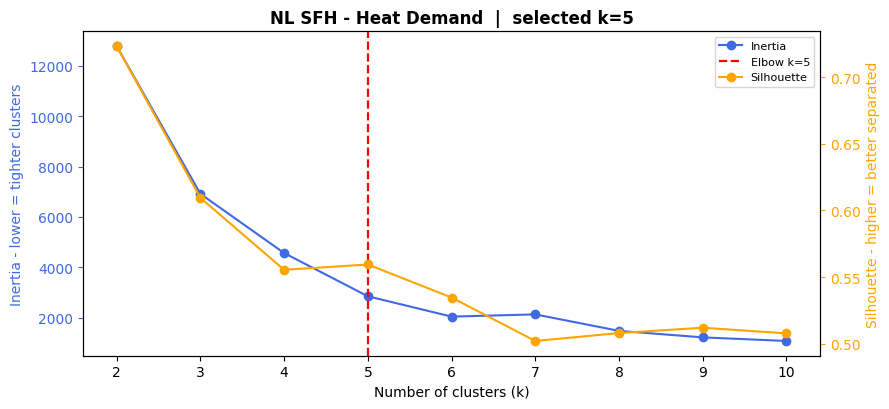

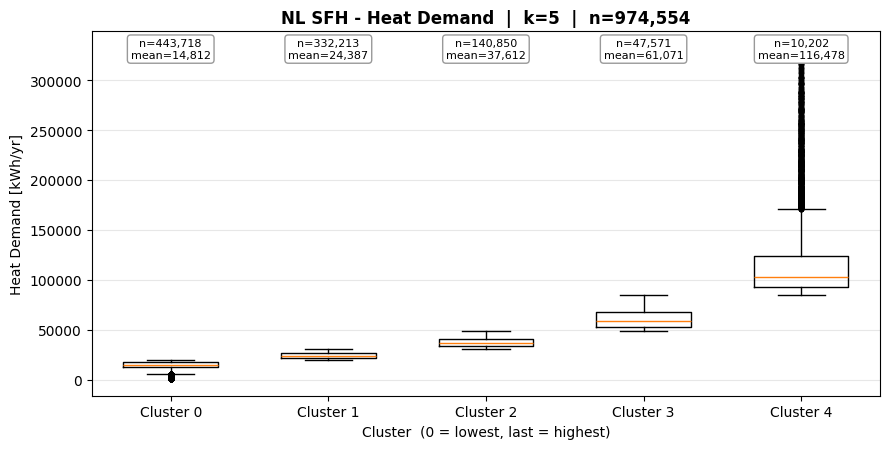


  TH  (4,257,386 buildings)
  Heat Demand            elbow k=4  silhouette preferred k=2  -> using k=4


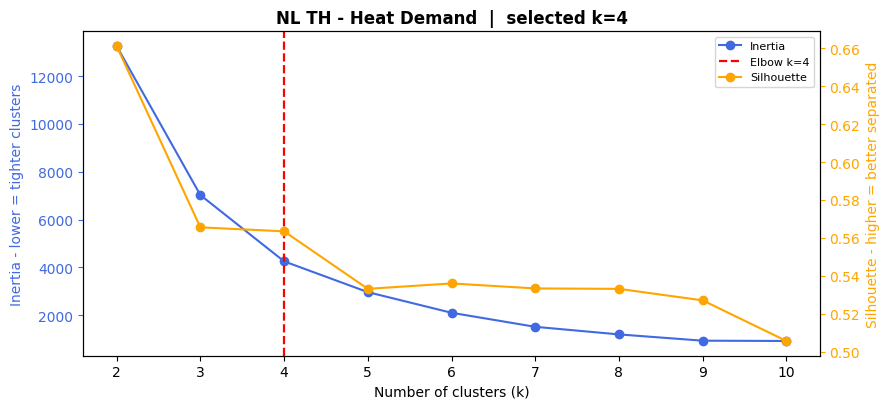

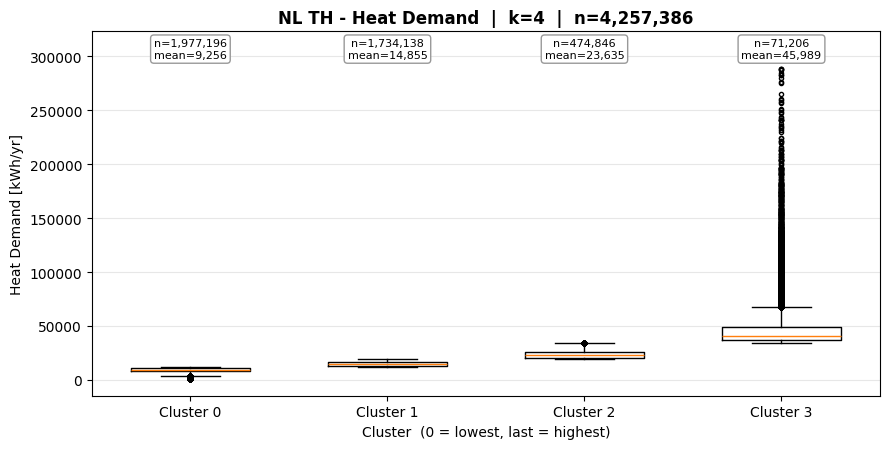


  MFH  (335,338 buildings)
  Heat Demand            elbow k=5  silhouette preferred k=2  -> using k=5


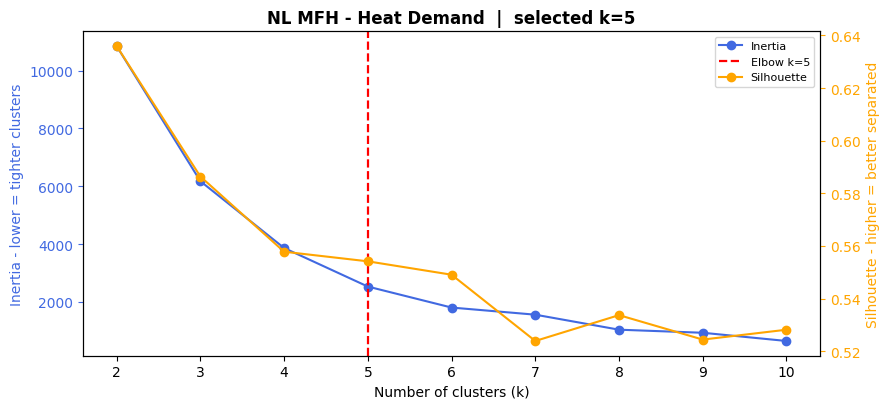

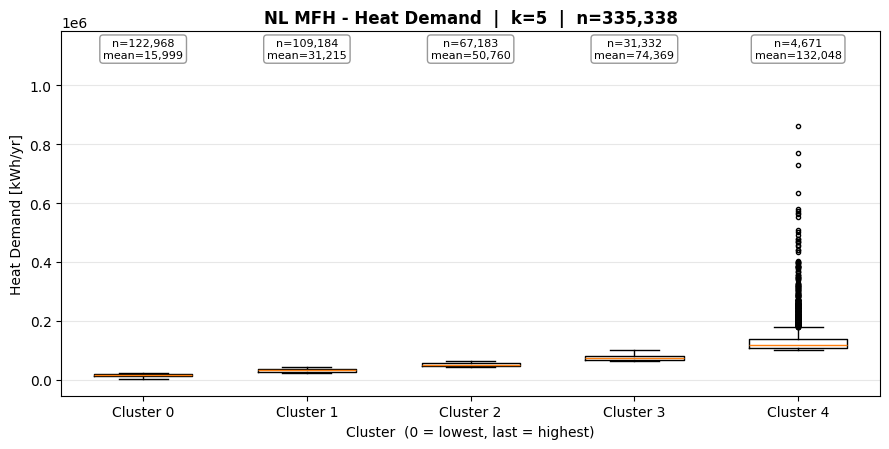


  AB  (49,376 buildings)
  Heat Demand            elbow k=4  silhouette preferred k=2  -> using k=4


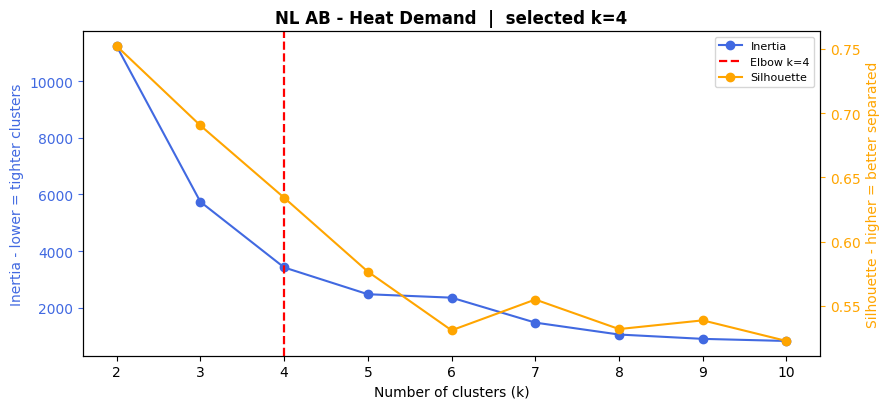

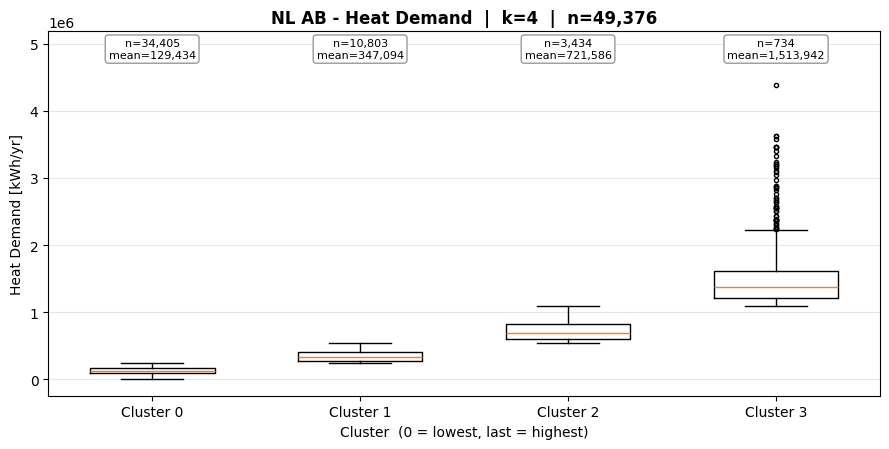

In [35]:
# reproduce the NRW figures per building type, on HEAT DEMAND (kWh/yr)
for sc in SIZE_CLASSES:
    g = m[m.building_type == sc]
    print("=" * 60)
    print("  %s  (%s buildings)" % (sc, format(len(g), ",")))
    print("=" * 60)
    hd = g["heat_kwh_yr"].to_numpy()
    if len(hd) < MIN_CLUSTER_MEMBERS * 2:
        print("  too few buildings to cluster\n"); continue
    k = kselect_and_plot(hd, "Heat Demand", "kWh/yr", "NL %s" % sc)
    cluster_boxplot(hd, k, "Heat Demand", "kWh/yr", "NL %s" % sc)
    print()


### 11.2 Post-clustering validation (NRW style)

The NRW workflow follows its clustering with four checks. We reproduce them on the heat-demand
clusters from 11.1:

1. **Gap analysis** — the relative jump between adjacent cluster means. Gaps below ~20% mean two
   clusters are barely distinct and could be merged.
2. **Cluster-size validation** — the smallest cluster per type, flagged when it holds too few
   buildings to be a reliable archetype.
3. **Combination count** — per-type vs whole-dataset, the NRW comparison.
4. **Refurbishment cross-tabulation** — heat cluster × TABULA refurbishment state, linking the
   demand clusters back to the `f` finding of Section 9.

> **One axis only.** NRW clusters on *both* heat and electricity demand, giving a two-variable
> product (e.g. "2 × 4 = 8"). The Dutch electricity demand is not yet built (CBS 81528ENG — see
> the report), so the combination count below is **heat-only**. The two-variable product can be
> completed once electricity data is added.


In [36]:
# fit the heat-demand clusters once per type and keep the labels, for all four checks below
def heat_clusters(values, k, seed=42):
    v = np.asarray(values, float); ok = np.isfinite(v)
    cap = np.percentile(v[ok], 99.9)
    X = StandardScaler().fit_transform(np.clip(v[ok], 0, cap).reshape(-1, 1))
    km = MiniBatchKMeans(k, random_state=seed, n_init=10, batch_size=MINIBATCH).fit(X)
    order = np.argsort([v[ok][km.labels_ == c].mean() for c in range(k)])
    relabel = {o: i for i, o in enumerate(order)}
    lab = np.full(len(v), -1)
    lab[ok] = np.vectorize(relabel.get)(km.labels_)
    return lab

# choose k per type by the same elbow rule used in 11.1
def elbow_k_only(values, kmin=2, kmax=10, sample=30000, seed=42):
    v = np.asarray(values, float); v = v[np.isfinite(v)]
    cap = np.percentile(v, 99.9)
    X = StandardScaler().fit_transform(np.clip(v, 0, cap).reshape(-1, 1))
    rng = np.random.default_rng(seed); Xs = X[rng.choice(len(v), min(sample, len(v)), replace=False)]
    ks = list(range(kmin, kmax + 1))
    inertia = [MiniBatchKMeans(k, random_state=seed, n_init=10, batch_size=MINIBATCH).fit(Xs).inertia_ for k in ks]
    x1, y1, x2, y2 = ks[0], inertia[0], ks[-1], inertia[-1]
    d = [abs((y2-y1)*k - (x2-x1)*i + x2*y1 - y2*x1) / np.hypot(x2-x1, y2-y1) for k, i in zip(ks, inertia)]
    return ks[int(np.argmax(d))]

heat_k = {}
heat_lab = {}
for sc in SIZE_CLASSES:
    hd = m.loc[m.building_type == sc, "heat_kwh_yr"].to_numpy()
    if len(hd) < MIN_CLUSTER_MEMBERS * 2:
        continue
    k = elbow_k_only(hd)
    heat_k[sc] = k
    heat_lab[sc] = heat_clusters(hd, k)

print("GAP ANALYSIS - relative difference between adjacent cluster means")
print("="*60)
for sc in SIZE_CLASSES:
    if sc not in heat_k: continue
    hd = m.loc[m.building_type == sc, "heat_kwh_yr"].to_numpy()
    lab = heat_lab[sc]; k = heat_k[sc]
    means = [hd[lab == c].mean() for c in range(k)]
    print(f"\n{sc}:")
    for c in range(k - 1):
        gap = (means[c+1] - means[c]) / means[c] * 100
        flag = "   <- SMALL GAP (< 20%)" if gap < 20 else ""
        print(f"  Heat Demand   C{c}->C{c+1}: {means[c]:>10,.0f} -> {means[c+1]:>10,.0f} kWh/yr  ({gap:.0f}%){flag}")
print("\nGaps >= 20% -> clusters are well separated and meaningful.")


GAP ANALYSIS - relative difference between adjacent cluster means

SFH:
  Heat Demand   C0->C1:     14,813 ->     24,388 kWh/yr  (65%)
  Heat Demand   C1->C2:     24,388 ->     37,613 kWh/yr  (54%)
  Heat Demand   C2->C3:     37,613 ->     61,071 kWh/yr  (62%)
  Heat Demand   C3->C4:     61,071 ->    116,479 kWh/yr  (91%)

TH:
  Heat Demand   C0->C1:      9,256 ->     14,856 kWh/yr  (60%)
  Heat Demand   C1->C2:     14,856 ->     23,636 kWh/yr  (59%)
  Heat Demand   C2->C3:     23,636 ->     45,989 kWh/yr  (95%)

MFH:
  Heat Demand   C0->C1:     16,000 ->     31,216 kWh/yr  (95%)
  Heat Demand   C1->C2:     31,216 ->     50,760 kWh/yr  (63%)
  Heat Demand   C2->C3:     50,760 ->     74,370 kWh/yr  (47%)
  Heat Demand   C3->C4:     74,370 ->    132,048 kWh/yr  (78%)

AB:
  Heat Demand   C0->C1:    129,434 ->    347,095 kWh/yr  (168%)
  Heat Demand   C1->C2:    347,095 ->    721,587 kWh/yr  (108%)
  Heat Demand   C2->C3:    721,587 ->  1,513,942 kWh/yr  (110%)

Gaps >= 20% -> clusters ar

In [37]:
print("CLUSTER SIZE VALIDATION")
print("="*60)
WARN = 100   # same floor used when pooling the archetype table
for sc in SIZE_CLASSES:
    if sc not in heat_k: continue
    lab = heat_lab[sc]; k = heat_k[sc]
    sizes = [(c, int((lab == c).sum())) for c in range(k)]
    cmin, nmin = min(sizes, key=lambda t: t[1])
    flag = f"   <- WARNING: very small cluster (< {WARN})" if nmin < WARN else ""
    print(f"\n{sc}:  smallest cluster C{cmin} with {nmin:,} buildings{flag}")
print("\nClusters below the pooling floor are merged upward in the archetype table (Section 12).")


CLUSTER SIZE VALIDATION

SFH:  smallest cluster C4 with 10,202 buildings

TH:  smallest cluster C3 with 71,206 buildings

MFH:  smallest cluster C4 with 4,671 buildings

AB:  smallest cluster C3 with 734 buildings

Clusters below the pooling floor are merged upward in the archetype table (Section 12).


In [38]:
print("COMBINATION COUNT  (heat-demand axis only; electricity not yet built)")
print("="*60)
total = 0
for sc in SIZE_CLASSES:
    if sc not in heat_k: continue
    print(f"  {sc}: heat k = {heat_k[sc]}")
    total += heat_k[sc]
print(f"\n  per-type sum (heat only) : {total}")
print("  NRW reference is a heat x electricity product (e.g. SFH 2 x 4 = 8);")
print("  add CBS 81528ENG electricity demand to complete the second axis.")


COMBINATION COUNT  (heat-demand axis only; electricity not yet built)
  SFH: heat k = 5
  TH: heat k = 4
  MFH: heat k = 5
  AB: heat k = 4

  per-type sum (heat only) : 18
  NRW reference is a heat x electricity product (e.g. SFH 2 x 4 = 8);
  add CBS 81528ENG electricity demand to complete the second axis.


In [39]:
print("REFURBISHMENT STATE CROSS-TABULATION  (heat cluster x TABULA state)")
print("="*60)
# TABULA state per building under f = F_REFURB: which of existing/usual/advanced applies.
# With f = 0 every pre-2000 building is 'existing'; this table shows the demand clusters
# do not silently mix refurbishment states within a cluster.
state = np.where(m.construction_year >= PRE_REFURB_YEAR, "new(>=2000)", "existing(f=0)")
mm = m.assign(_state=state)
mm["_hc"] = -1
for sc in SIZE_CLASSES:
    if sc in heat_lab:
        mm.loc[mm.building_type == sc, "_hc"] = heat_lab[sc]
ct = pd.crosstab(mm._hc[mm._hc >= 0], mm._state[mm._hc >= 0], normalize="index") * 100
ct.index.name = "Heat cluster"
print("\n% of each heat cluster by construction era:")
print(ct.round(1).to_string())
print("\nUnder f = 0 there is no interpolation, so 'era' is the only refurbishment axis.")
print("With a nonzero f (or per-building EP-Online states), this table would show how")
print("refurbishment distributes across the demand clusters.")


REFURBISHMENT STATE CROSS-TABULATION  (heat cluster x TABULA state)

% of each heat cluster by construction era:
_state        existing(f=0)  new(>=2000)
Heat cluster                            
0                      68.1         31.9
1                      95.2          4.8
2                      98.2          1.8
3                      97.9          2.1
4                      97.1          2.9

Under f = 0 there is no interpolation, so 'era' is the only refurbishment axis.
With a nonzero f (or per-building EP-Online states), this table would show how
refurbishment distributes across the demand clusters.


## 14. Known limitations & next steps

**Read this before quoting any number.** The pipeline is validated, but several figures carry
caveats that do not appear in the outputs above.

**Numbers that need a footnote**
- **Space heat is CALCULATED demand (~106 TWh), not measured (~48 TWh).** The 2.2x gap is the
  prebound effect (Majcen, Itard & Visscher 2013), not an error. Which figure SESMG consumes —
  asset demand for sizing, occupant demand for real consumption — is a modelling decision.
- **`f = 0` is an EP-Online result, not a default.** Section 9 shows the pre-2000 stock sits at
  TABULA's unrefurbished intensity. Do not "restore" a nonzero refurbishment share without
  re-checking against the register.
- **DHW is ~4% high**: BAG counts ~4% more residential objects than CBS counts dwellings, and
  DHW scales with dwellings. Space heat is unaffected (it scales with area).
- **557 Mm2 of PV area is GROSS tilted roof surface.** Apply a 40-60% utilisation factor
  (obstructions, spacing, setbacks) before any installable-capacity or yield figure.
- **TABULA period 06 is hand-filled** and ~13% high per the register. The 05->06 intensity
  inversion is visible in Section 13. Consider replacing those six values with EP-Online medians.
- **Cluster NUMBERING is not stable across runs.** MiniBatchKMeans is stochastic, so a given
  cluster's index (c0, c1, ...) may differ between runs even with a fixed seed. The partition and
  all totals are reproducible; only the labels permute. Do not join two runs on cluster id.

**Not yet built (not started)**
- **Electricity demand** — the largest gap. CBS StatLine table 81528ENG. Required to complete the
  two-variable clustering in Section 11.2 (currently heat-only).
- **Hourly disaggregation** — NEDU standaardjaarprofielen (gas G1a, electricity E1a/E1b). Required
  before the annual archetype table can enter SESMG, which is hourly.
- **PV yield** — needs the utilisation factor above, plus a geometry-quality sensitivity run.
- **Geothermal potential** — PDOK cadastral parcels; the NRW lawn-area method transfers directly.
- **District heating / heat pumps (~9% of dwellings)** currently carry a gas-boiler demand.

